# Time-series diagnostics

Explore the training series through plots, decomposition, ACF/PACF, stationarity tests, transformations and correlations. No forecasting models are fitted.

## Imports and configuration

In [1]:
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("../data/raw/kazakhstan_npl_oil_fx_quarterly.csv")
FIGURE_DIRECTORY = Path("../reports/figures")
EXPECTED_COLUMNS = ["quarter", "npl", "brent", "usdkzt"]
VALUE_COLUMNS = EXPECTED_COLUMNS[1:]
TRAIN_END = pd.Period("2021Q4", freq="Q-DEC")
ALPHA = 0.05
MAX_LAGS = 8
ADF_MAX_LAGS = 4
CORRELATION_MAX_LAG = 4
SEASONAL_PERIOD = 4

COLORS = {"npl": "#E45756", "brent": "#4C78A8", "usdkzt": "#59A14F"}
LEVEL_LABELS = {
    "npl": "NPL 90+ (%)",
    "brent": "Brent (USD/barrel)",
    "usdkzt": "USD/KZT (KZT per USD)",
}

assert DATA_PATH.exists(), f"Missing input: {DATA_PATH}"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)


def save_figure(figure, filename):
    # save and display the chart, then release its memory
    figure.tight_layout()
    figure.savefig(FIGURE_DIRECTORY / filename, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(figure)


def plot_acf_pacf(frame, columns, labels, filename):
    # inspect quarterly dependence without selecting a model
    figure, axes = plt.subplots(len(columns), 2, figsize=(12, 9))
    for row, column in enumerate(columns):
        values = frame[column].dropna()
        assert values.index.max() <= TRAIN_END
        assert MAX_LAGS < len(values) // 2
        plot_acf(
            values,
            lags=MAX_LAGS,
            zero=False,
            alpha=ALPHA,
            ax=axes[row, 0],
            title=f"{labels[column]}: ACF",
        )
        plot_pacf(
            values,
            lags=MAX_LAGS,
            zero=False,
            alpha=ALPHA,
            method="ywm",
            ax=axes[row, 1],
            title=f"{labels[column]}: PACF",
        )
        for axis in axes[row]:
            axis.set(xlabel="Quarterly lag", ylabel="Correlation")
    save_figure(figure, filename)

## Dataset split

Training: 2010Q1–2021Q4. Test: 2022Q1–2026Q2. All diagnostics below use training data only.

In [2]:
quarterly_data = pd.read_csv(DATA_PATH)
display(quarterly_data.head())
quarterly_data.info()

assert quarterly_data.columns.tolist() == EXPECTED_COLUMNS
assert quarterly_data["quarter"].str.fullmatch(r"\d{4}Q[1-4]").all()
assert quarterly_data[VALUE_COLUMNS].select_dtypes(include=np.number).shape[1] == 3
assert not quarterly_data.isna().any().any()
assert np.isfinite(quarterly_data[VALUE_COLUMNS].to_numpy()).all()
assert quarterly_data["npl"].between(0, 100).all()
assert quarterly_data[["brent", "usdkzt"]].gt(0).all().all()

quarter_index = pd.PeriodIndex(quarterly_data["quarter"], freq="Q-DEC")
expected_quarters = pd.period_range("2010Q1", "2026Q2", freq="Q-DEC")
assert quarter_index.equals(expected_quarters)
assert quarter_index.is_unique

# split chronologically before calculating diagnostics
time_series_data = quarterly_data[VALUE_COLUMNS].copy()
time_series_data.index = quarter_index
time_series_data.index.name = "quarter"
train_data = time_series_data.loc[time_series_data.index <= TRAIN_END].copy()
test_data = time_series_data.loc[time_series_data.index > TRAIN_END].copy()

assert len(train_data) == 48 and len(test_data) == 18
assert train_data.index.intersection(test_data.index).empty
assert train_data.index.max() < test_data.index.min()

split_summary = pd.DataFrame([
    {
        "sample": name,
        "start": str(sample.index.min()),
        "end": str(sample.index.max()),
        "quarters": len(sample),
    }
    for name, sample in [("training", train_data), ("test", test_data)]
]).set_index("sample")
display(split_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   quarter  66 non-null     object 
 1   npl      66 non-null     float64
 2   brent    66 non-null     float64
 3   usdkzt   66 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.2+ KB


,quarter,npl,brent,usdkzt
0,2010Q1,24.9600,76.6700,147.7000
1,2010Q2,25.2500,78.8500,146.8100
2,2010Q3,25.8300,76.6800,147.4100
3,2010Q4,23.7500,87.0300,147.4900
4,2011Q1,25.2700,105.3700,146.4200


,start,end,quarters
sample,,,
training,2010Q1,2021Q4,48
test,2022Q1,2026Q2,18


## Training-period plots

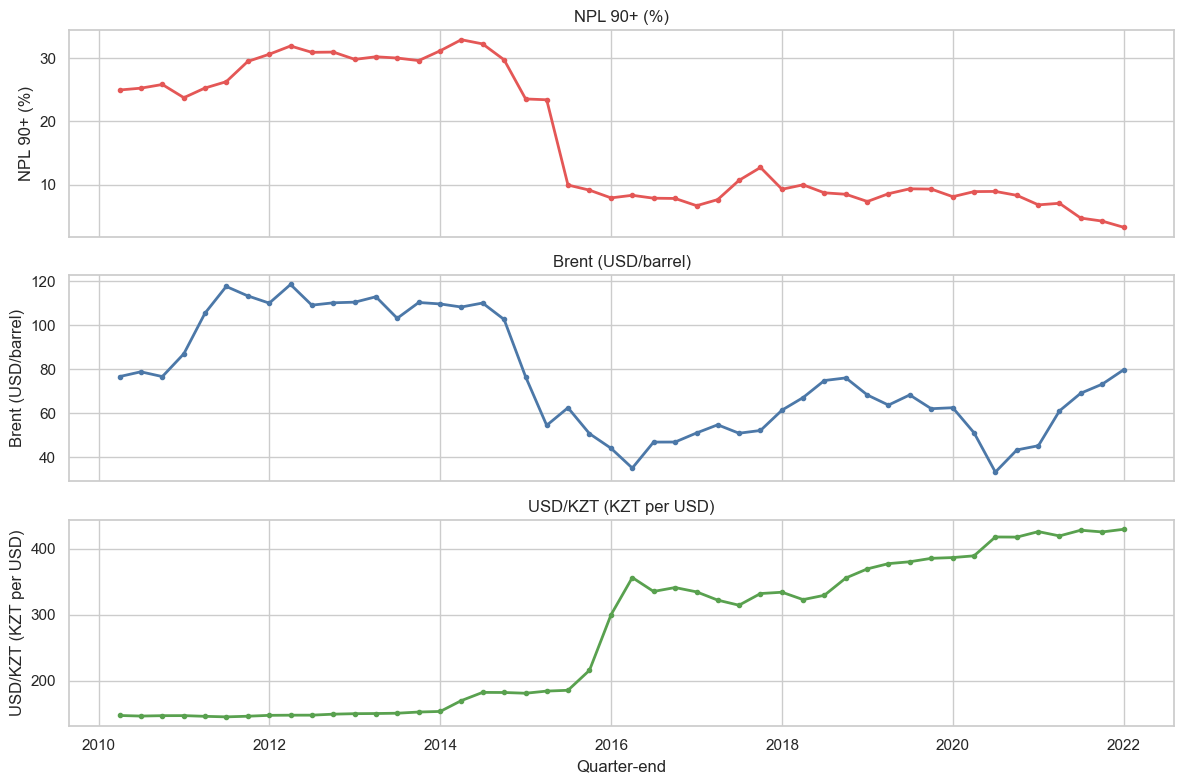

In [3]:
training_dates = train_data.index.to_timestamp(how="end").normalize()
figure, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# retain original levels and genuine jumps
for axis, column in zip(axes, VALUE_COLUMNS):
    axis.plot(
        training_dates, train_data[column], color=COLORS[column],
        linewidth=2, marker="o", markersize=3,
    )
    axis.set(title=LEVEL_LABELS[column], ylabel=LEVEL_LABELS[column])

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Quarter-end")
save_figure(figure, "02_training_series.png")

## ACF/PACF: levels

Inspect persistence and possible annual seasonal lags (4 and 8 quarters). Trends and level shifts can also produce large correlations; spikes alone do not determine model orders.

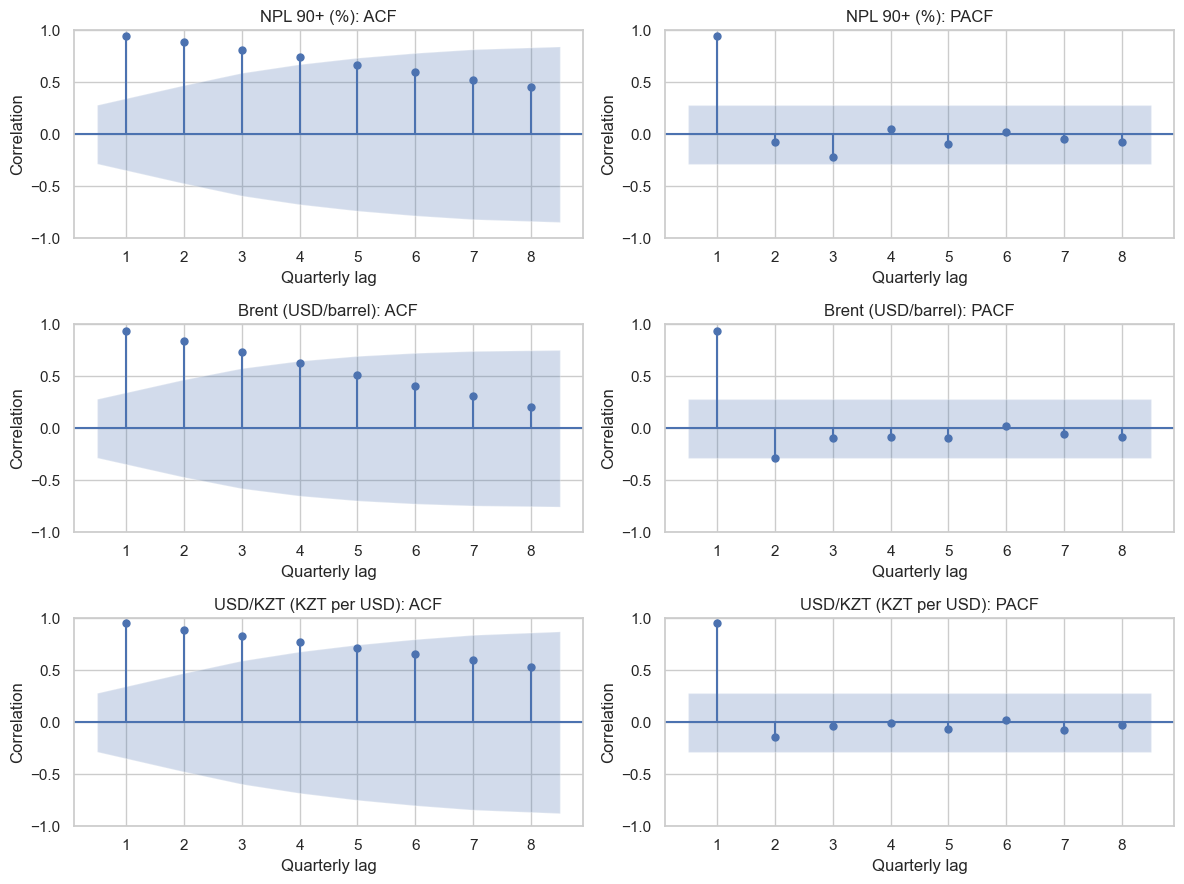

In [4]:
plot_acf_pacf(
    train_data, VALUE_COLUMNS, LEVEL_LABELS,
    "02_acf_pacf_levels.png",
)

## STL decomposition

Exploratory [STL](https://www.statsmodels.org/v0.14.0/generated/statsmodels.tsa.seasonal.STL.html) with a four-quarter period. A seasonal component is estimated by construction, so this is not a seasonality or structural-break test. The remainder cannot be interpreted as an identified economic shock.

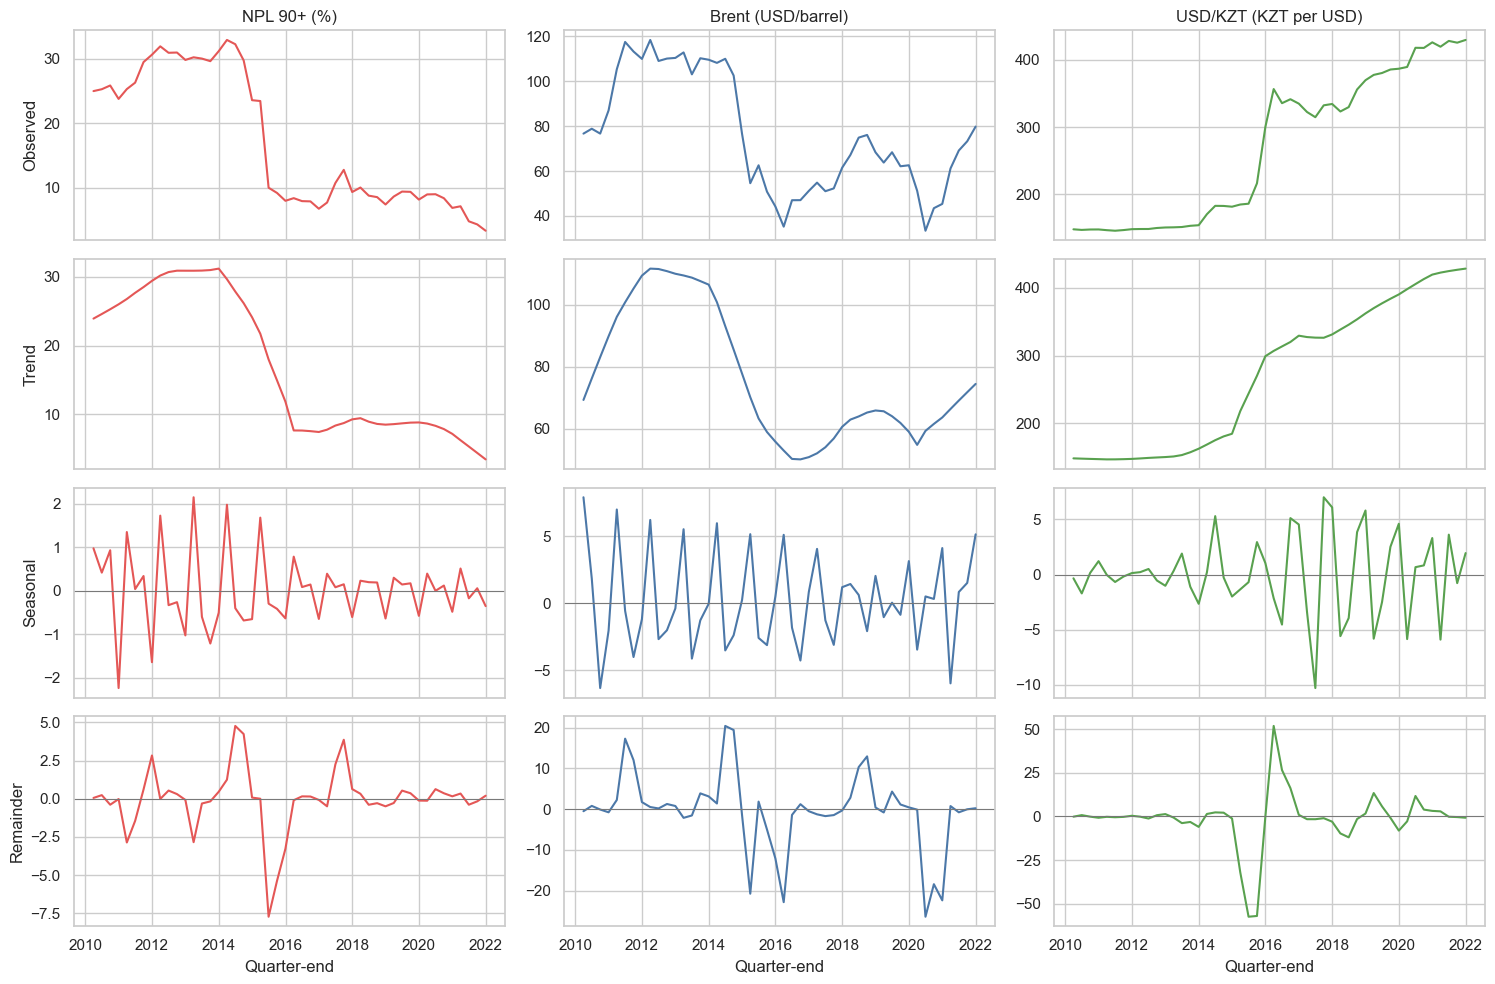

In [5]:
decomposition_results = {}
component_names = ["observed", "trend", "seasonal", "remainder"]
figure, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=True)

# decompose each training series without adjusting the input data
for column_index, column in enumerate(VALUE_COLUMNS):
    result = STL(
        train_data[column].to_numpy(), period=SEASONAL_PERIOD, robust=True
    ).fit()
    components = pd.DataFrame({
        "observed": train_data[column].to_numpy(),
        "trend": result.trend,
        "seasonal": result.seasonal,
        "remainder": result.resid,
    }, index=train_data.index)
    assert np.isfinite(components.to_numpy()).all()
    assert np.allclose(
        components["observed"],
        components[["trend", "seasonal", "remainder"]].sum(axis=1),
    )
    decomposition_results[column] = components

    for row, component in enumerate(component_names):
        axis = axes[row, column_index]
        axis.plot(training_dates, components[component], color=COLORS[column])
        if column_index == 0:
            axis.set_ylabel(component.title())
        if row == 0:
            axis.set_title(LEVEL_LABELS[column])
        if row >= 2:
            axis.axhline(0, color="#777777", linewidth=0.7)

    axes[-1, column_index].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[-1, column_index].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1, column_index].set_xlabel("Quarter-end")

save_figure(figure, "02_stl_decomposition.png")

## Stationarity tests: levels

ADF tests the unit-root null; KPSS tests the stationarity null. Use a constant (`c`) or a constant and trend (`ct`), with a 5% significance level. KPSS p-value bounds are shown explicitly. Neither test establishes a structural break.

In [6]:
def stationarity_table(frame, specifications):
    # compare both tests without treating non-rejection as proof
    rows = []
    for column, deterministic in specifications:
        values = frame[column].dropna()
        assert values.index.max() <= TRAIN_END
        assert np.isfinite(values.to_numpy()).all()

        adf_result = adfuller(
            values, maxlag=ADF_MAX_LAGS, regression=deterministic, autolag="BIC"
        )
        with warnings.catch_warnings(record=True) as recorded:
            warnings.simplefilter("always")
            kpss_result = kpss(values, regression=deterministic, nlags="auto")

        # report tabulated bounds instead of repeating interpolation warnings
        for warning in recorded:
            if not issubclass(warning.category, InterpolationWarning):
                warnings.warn(warning.message, warning.category)

        adf_reject = adf_result[1] < ALPHA
        kpss_reject = kpss_result[1] < ALPHA
        if adf_reject and not kpss_reject:
            evidence = "supports stationarity"
        elif not adf_reject and kpss_reject:
            evidence = "supports nonstationarity"
        elif adf_reject and kpss_reject:
            evidence = "conflicting"
        else:
            evidence = "inconclusive"

        kpss_p = f"{kpss_result[1]:.4f}"
        if kpss_result[1] <= 0.01:
            kpss_p = "<=0.01"
        elif kpss_result[1] >= 0.10:
            kpss_p = ">=0.10"

        rows.append({
            "series": column,
            "deterministic": deterministic,
            "n": len(values),
            "adf_stat": adf_result[0],
            "adf_p": adf_result[1],
            "adf_lags": adf_result[2],
            "kpss_stat": kpss_result[0],
            "kpss_p": kpss_p,
            "kpss_lags": kpss_result[2],
            "evidence": evidence,
        })
    return pd.DataFrame(rows)


level_stationarity = stationarity_table(
    train_data,
    [
        (column, deterministic)
        for column in VALUE_COLUMNS
        for deterministic in ["c", "ct"]
    ],
)
display(level_stationarity)

,series,deterministic,n,adf_stat,adf_p,adf_lags,kpss_stat,kpss_p,kpss_lags,evidence
0,npl,c,48,-0.4542,0.9007,0,0.8465,<=0.01,4,supports nonstationarity
1,npl,ct,48,-2.5657,0.2959,2,0.1031,>=0.10,4,inconclusive
2,brent,c,48,-1.2013,0.6730,0,0.5839,0.0241,4,supports nonstationarity
3,brent,ct,48,-1.5209,0.8219,0,0.1106,>=0.10,4,inconclusive
4,usdkzt,c,48,-0.5713,0.8773,1,1.0025,<=0.01,4,supports nonstationarity
5,usdkzt,ct,48,-3.0154,0.1278,1,0.1118,>=0.10,4,inconclusive


## Candidate transformations

Retain the original levels. NPL first differences are measured in percentage points; oil/FX log differences ×100 approximate quarter-on-quarter percentage changes. These are candidate specifications, not a final model choice.

In [7]:
diagnostic_data = train_data.copy()

# calculate transformations using training observations only
diagnostic_data["log_brent"] = np.log(train_data["brent"])
diagnostic_data["log_usdkzt"] = np.log(train_data["usdkzt"])
diagnostic_data["npl_change_pp"] = train_data["npl"].diff()
diagnostic_data["brent_log_change_pct"] = diagnostic_data["log_brent"].diff() * 100
diagnostic_data["usdkzt_log_change_pct"] = diagnostic_data["log_usdkzt"].diff() * 100

CHANGE_COLUMNS = [
    "npl_change_pp",
    "brent_log_change_pct",
    "usdkzt_log_change_pct",
]
CHANGE_LABELS = {
    "npl_change_pp": "NPL change (percentage points)",
    "brent_log_change_pct": "Brent change (100 × log difference)",
    "usdkzt_log_change_pct": "USD/KZT change (100 × log difference)",
}

pd.testing.assert_frame_equal(diagnostic_data[VALUE_COLUMNS], train_data)
assert diagnostic_data[CHANGE_COLUMNS].iloc[0].isna().all()
assert diagnostic_data[CHANGE_COLUMNS].iloc[1:].notna().all().all()
assert np.isfinite(diagnostic_data.dropna().to_numpy()).all()
display(diagnostic_data.head())

,npl,brent,usdkzt,log_brent,log_usdkzt,npl_change_pp,brent_log_change_pct,usdkzt_log_change_pct
quarter,,,,,,,,
2010Q1,24.9600,76.6700,147.7000,4.3395,4.9952,NaN,NaN,NaN
2010Q2,25.2500,78.8500,146.8100,4.3675,4.9891,0.2900,2.8037,-0.6044
2010Q3,25.8300,76.6800,147.4100,4.3396,4.9932,0.5800,-2.7906,0.4079
2010Q4,23.7500,87.0300,147.4900,4.4663,4.9938,-2.0800,12.6612,0.0543
2011Q1,25.2700,105.3700,146.4200,4.6575,4.9865,1.5200,19.1225,-0.7281


## Transformed-series plots

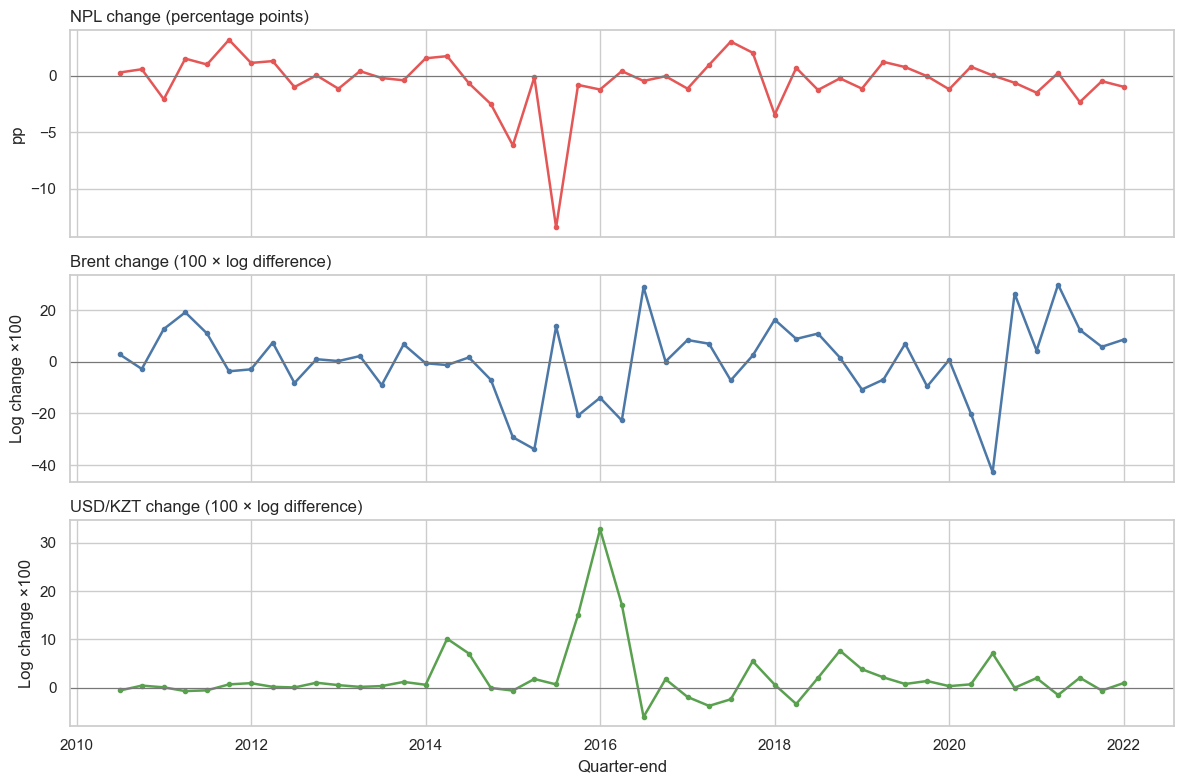

In [8]:
figure, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for axis, column, original_column in zip(axes, CHANGE_COLUMNS, VALUE_COLUMNS):
    axis.plot(
        training_dates, diagnostic_data[column], color=COLORS[original_column],
        linewidth=1.8, marker="o", markersize=3,
    )
    axis.axhline(0, color="#777777", linewidth=0.8)
    axis.set_title(CHANGE_LABELS[column], loc="left")
    axis.set_ylabel("pp" if column == "npl_change_pp" else "Log change ×100")

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Quarter-end")
save_figure(figure, "02_candidate_transformations.png")

## ACF/PACF: changes

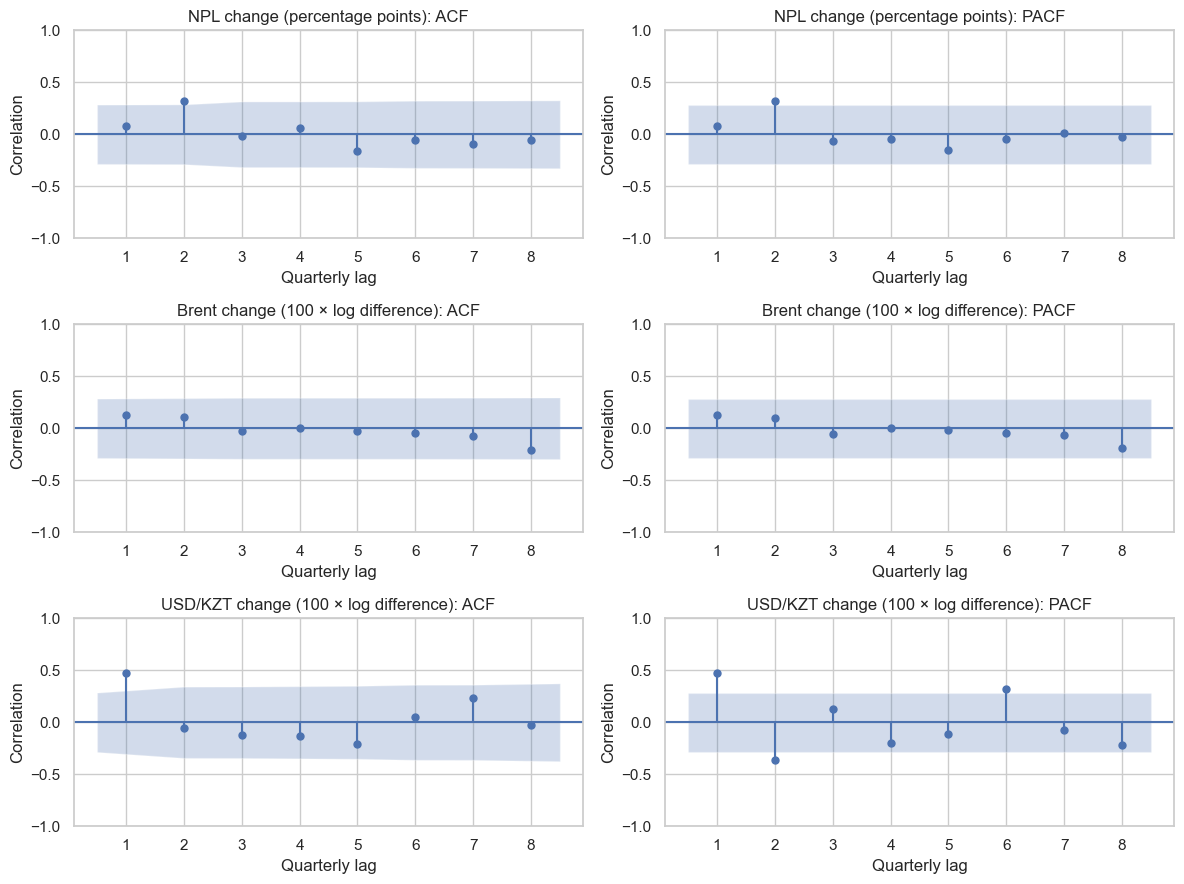

In [9]:
plot_acf_pacf(
    diagnostic_data, CHANGE_COLUMNS, CHANGE_LABELS,
    "02_acf_pacf_changes.png",
)

## Stationarity tests: transformations

In [10]:
transformed_stationarity = stationarity_table(
    diagnostic_data,
    [
        (column, deterministic)
        for column in ["log_brent", "log_usdkzt"]
        for deterministic in ["c", "ct"]
    ]
    + [(column, "c") for column in CHANGE_COLUMNS],
)
display(transformed_stationarity)

,series,deterministic,n,adf_stat,adf_p,adf_lags,kpss_stat,kpss_p,kpss_lags,evidence
0,log_brent,c,48,-1.4259,0.5698,0,0.5500,0.0304,4,supports nonstationarity
1,log_brent,ct,48,-1.6131,0.7873,0,0.1054,>=0.10,4,inconclusive
2,log_usdkzt,c,48,-0.5041,0.8912,2,0.9959,<=0.01,4,supports nonstationarity
3,log_usdkzt,ct,48,-2.7569,0.2132,1,0.1119,>=0.10,4,inconclusive
4,npl_change_pp,c,47,-3.1715,0.0217,1,0.1085,>=0.10,3,supports stationarity
5,brent_log_change_pct,c,47,-5.8299,0.0000,0,0.1081,>=0.10,2,supports stationarity
6,usdkzt_log_change_pct,c,47,-4.8748,0.0000,1,0.1012,>=0.10,2,supports stationarity


## Correlation matrix

Contemporaneous Pearson correlations between NPL changes and oil/FX log changes, using 47 common training quarters. These are associations, not causal effects or evidence of forecast performance.

,npl_change_pp,brent_log_change_pct,usdkzt_log_change_pct
npl_change_pp,1.0000,-0.0605,0.0003
brent_log_change_pct,-0.0605,1.0000,-0.4206
usdkzt_log_change_pct,0.0003,-0.4206,1.0000


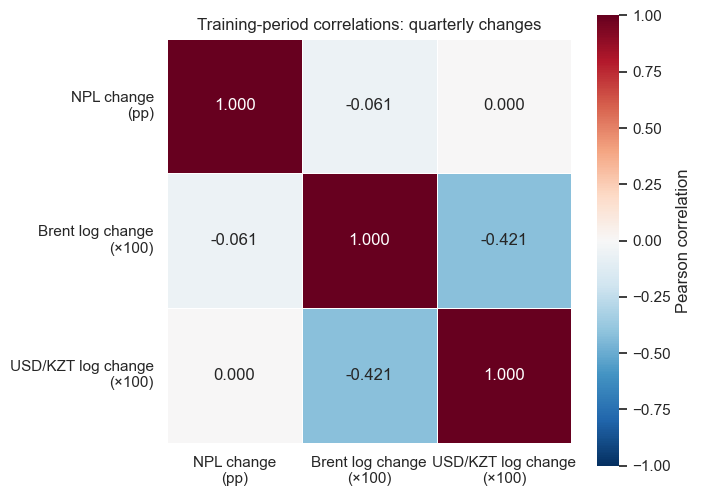

In [11]:
# align all transformed series on the same complete training quarters
correlation_data = diagnostic_data[CHANGE_COLUMNS].dropna().copy()
assert len(correlation_data) == len(train_data) - 1 == 47
assert correlation_data.index.min() == pd.Period("2010Q2", freq="Q-DEC")
assert correlation_data.index.max() == TRAIN_END
assert correlation_data.index.intersection(test_data.index).empty
assert np.isfinite(correlation_data.to_numpy()).all()

correlation_matrix = correlation_data.corr(method="pearson")
assert np.allclose(correlation_matrix, correlation_matrix.T)
assert np.allclose(np.diag(correlation_matrix), 1)
display(correlation_matrix)

# show signed correlations on a fixed scale
correlation_labels = {
    "npl_change_pp": "NPL change\n(pp)",
    "brent_log_change_pct": "Brent log change\n(×100)",
    "usdkzt_log_change_pct": "USD/KZT log change\n(×100)",
}
plot_matrix = correlation_matrix.rename(
    index=correlation_labels, columns=correlation_labels
)
figure, axis = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    plot_matrix, annot=True, fmt=".3f", cmap="RdBu_r",
    vmin=-1, vmax=1, center=0, square=True,
    linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=axis,
)
axis.set_title("Training-period correlations: quarterly changes")
axis.tick_params(axis="both", labelrotation=0)
save_figure(figure, "02_transformed_correlation_matrix.png")

## Lagged correlations

Compare NPL changes at quarter $t$ with oil/FX changes at $t-k$, for lags 0–4. Every cell uses the same 43 NPL observation quarters (2011Q2–2021Q4), so lag-0 values differ from the 47-quarter matrix above.

Lag 0 is contemporaneous; using it in a forecast requires future macro values or assumptions. Select model lags through chronological validation, not the largest correlation.

,first_target_quarter,last_target_quarter,pairs_per_cell
0,2011Q2,2021Q4,43


,Brent log change (×100),USD/KZT log change (×100)
Macro lag (quarters),,
0,-0.0740,0.0102
1,0.2737,-0.0641
2,0.2993,-0.0256
3,0.1190,-0.0432
4,0.0983,-0.1478


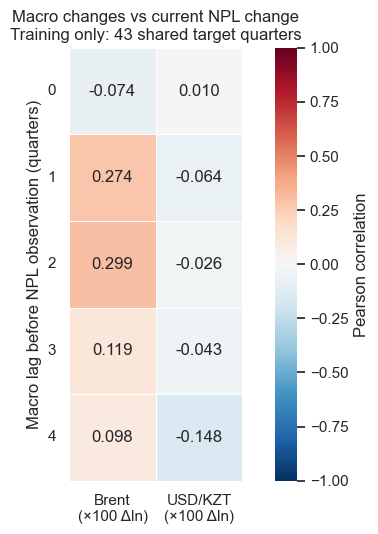

In [12]:
MACRO_CHANGE_COLUMNS = [
    "brent_log_change_pct",
    "usdkzt_log_change_pct",
]
MACRO_CHANGE_LABELS = {
    "brent_log_change_pct": "Brent log change (×100)",
    "usdkzt_log_change_pct": "USD/KZT log change (×100)",
}

# pair current npl changes with earlier macro changes, using training data only
lagged_correlation_data = diagnostic_data[["npl_change_pp"]].copy()
for column in MACRO_CHANGE_COLUMNS:
    for lag in range(CORRELATION_MAX_LAG + 1):
        lagged_correlation_data[f"{column}_lag_{lag}"] = (
            diagnostic_data[column].shift(lag)
        )

# keep identical target quarters for every variable and lag
lagged_correlation_data = lagged_correlation_data.dropna()
assert len(lagged_correlation_data) == len(correlation_data) - CORRELATION_MAX_LAG
assert lagged_correlation_data.index.min() == (
    correlation_data.index.min() + CORRELATION_MAX_LAG
)
assert lagged_correlation_data.index.max() == TRAIN_END
assert lagged_correlation_data.index.intersection(test_data.index).empty
assert np.isfinite(lagged_correlation_data.to_numpy()).all()

lagged_correlations = pd.DataFrame(
    {
        MACRO_CHANGE_LABELS[column]: [
            lagged_correlation_data["npl_change_pp"].corr(
                lagged_correlation_data[f"{column}_lag_{lag}"]
            )
            for lag in range(CORRELATION_MAX_LAG + 1)
        ]
        for column in MACRO_CHANGE_COLUMNS
    },
    index=pd.Index(
        range(CORRELATION_MAX_LAG + 1), name="Macro lag (quarters)"
    ),
)
assert np.isfinite(lagged_correlations.to_numpy()).all()
assert lagged_correlations.abs().le(1).all().all()
display(pd.DataFrame({
    "first_target_quarter": [str(lagged_correlation_data.index.min())],
    "last_target_quarter": [str(lagged_correlation_data.index.max())],
    "pairs_per_cell": [len(lagged_correlation_data)],
}))
display(lagged_correlations)

# show macro changes leading npl changes, without choosing a preferred lag
plot_lagged_correlations = lagged_correlations.rename(columns={
    MACRO_CHANGE_LABELS["brent_log_change_pct"]: "Brent\n(×100 Δln)",
    MACRO_CHANGE_LABELS["usdkzt_log_change_pct"]: "USD/KZT\n(×100 Δln)",
})
figure, axis = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    plot_lagged_correlations, annot=True, fmt=".3f", cmap="RdBu_r",
    vmin=-1, vmax=1, center=0, square=True,
    linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=axis,
)
axis.set_title(
    "Macro changes vs current NPL change\n"
    f"Training only: {len(lagged_correlation_data)} shared target quarters"
)
axis.set_xlabel("")
axis.set_ylabel("Macro lag before NPL observation (quarters)")
axis.tick_params(axis="both", labelrotation=0)
save_figure(figure, "02_lagged_change_correlations.png")

## Conclusion

Stationarity tests support using quarterly changes as candidates, while level-series results depend on the trend specification. Oil and FX changes are moderately negatively correlated; NPL associations are weak and exploratory. Genuine jumps remain in the data. Notebook 3 will compare simple regression and ARX specifications using pre-2022 chronological validation.